In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

In [2]:
df = pd.read_csv("../data/processed/cpi_oni.csv")
df["date"] = pd.to_datetime(df["date"])

df = (
    df.sort_values("date")
      .reset_index(drop=True)
)

display(df.head())
display(df.tail())

,date,food_inflation,oni,month
0,2012-01-01,-0.21,-0.72,1
1,2012-02-01,4.45,-0.57,2
2,2012-03-01,7.09,-0.46,3
3,2012-04-01,9.32,-0.36,4
4,2012-05-01,9.70,-0.17,5


,date,food_inflation,oni,month
163,2025-08-01,-0.64,-0.28,8
164,2025-09-01,-2.33,-0.40,9
165,2025-10-01,-5.02,-0.51,10
166,2025-11-01,-3.91,-0.55,11
167,2025-12-01,-2.71,-0.54,12


In [3]:
print("Shape:", df.shape)

print("\nMissing values:")
print(df.isna().sum())

print("\nDate range:")
print(df["date"].min(), "to", df["date"].max())

Shape: (168, 4)

Missing values:
date              0
food_inflation    0
oni               0
month             0
dtype: int64

Date range:
2012-01-01 00:00:00 to 2025-12-01 00:00:00


In [4]:
TEST_SIZE = 24

train_df = df.iloc[:-TEST_SIZE].copy()
test_df = df.iloc[-TEST_SIZE:].copy()

print("Training:")
print(train_df["date"].min(), "→", train_df["date"].max())

print("\nTesting:")
print(test_df["date"].min(), "→", test_df["date"].max())

Training:
2012-01-01 00:00:00 → 2023-12-01 00:00:00

Testing:
2024-01-01 00:00:00 → 2025-12-01 00:00:00


In [5]:
features = ["food_inflation", "oni"]

feature_scaler = MinMaxScaler()

train_scaled = feature_scaler.fit_transform(
    train_df[features]
)

test_scaled = feature_scaler.transform(
    test_df[features]
)

In [6]:
target_scaler = MinMaxScaler()

target_scaler.fit(
    train_df[["food_inflation"]]
)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [7]:
def create_sequences(
    features,
    target,
    lookback
):
    X = []
    y = []

    for i in range(
        lookback,
        len(features)
    ):
        X.append(
            features[i - lookback:i]
        )

        y.append(
            target[i]
        )

    return (
        np.array(X),
        np.array(y)
    )

LOOKBACK = 12

In [8]:
train_target_scaled = target_scaler.transform(
    train_df[["food_inflation"]]
).flatten()

In [9]:
X_train_full, y_train_full = create_sequences(
    train_scaled,
    train_target_scaled,
    LOOKBACK
)

print("X shape:", X_train_full.shape)
print("y shape:", y_train_full.shape)

X shape: (132, 12, 2)
y shape: (132,)


In [10]:
VALIDATION_SIZE = 24

X_train = X_train_full[:-VALIDATION_SIZE]
y_train = y_train_full[:-VALIDATION_SIZE]

X_val = X_train_full[-VALIDATION_SIZE:]
y_val = y_train_full[-VALIDATION_SIZE:]

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 108
Validation samples: 24


In [11]:
model = Sequential([
    LSTM(
        64,
        input_shape=(
            LOOKBACK,
            len(features)
        )
    ),

    Dropout(0.2),

    Dense(32, activation="relu"),

    Dense(1)
])

In [12]:
model.compile(
    optimizer="adam",
    loss="mse"
)

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,265 (75.25 KB)

 Trainable params: 19,265 (75.25 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

In [15]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(
        X_val,
        y_val
    ),
    epochs=300,
    batch_size=16,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 0.1006 - val_loss: 0.0473
Epoch 2/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0321 - val_loss: 0.0130
Epoch 3/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0320 - val_loss: 0.0257
Epoch 4/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0250 - val_loss: 0.0309
Epoch 5/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0206 - val_loss: 0.0192
Epoch 6/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0234 - val_loss: 0.0165
Epoch 7/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0223 - val_loss: 0.0226
Epoch 8/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0208 - val_loss: 0.0192
Epoch 9/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0186 - val_loss: 0.0168
Epoch 10/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0194 - val_loss: 0.0191
Epoch 11/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0204 - val_loss: 0.0179
Epoch 12/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0205 - val_lo

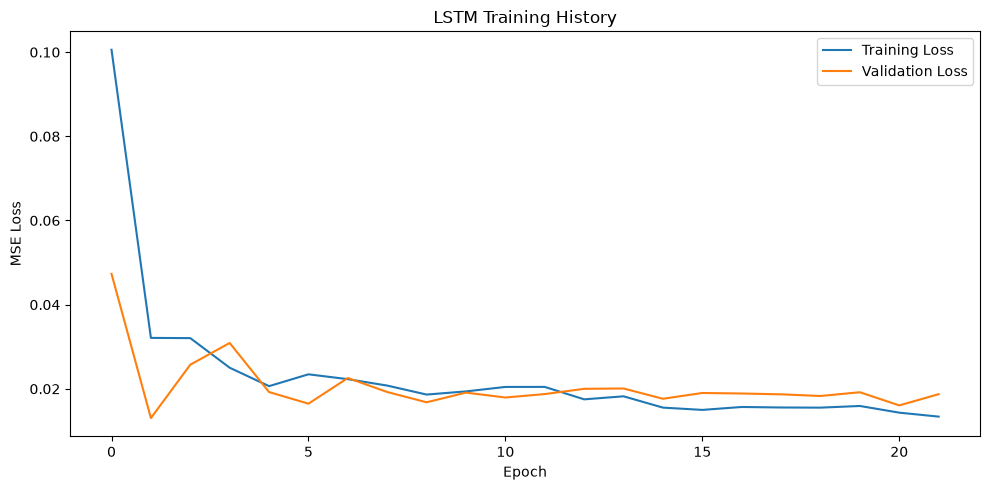

In [16]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training History")
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
combined = pd.concat(
    [
        train_df.tail(LOOKBACK),
        test_df
    ],
    ignore_index=True
)

combined_scaled = feature_scaler.transform(
    combined[features]
)

In [18]:
X_test, _ = create_sequences(
    combined_scaled,
    np.zeros(len(combined_scaled)),
    LOOKBACK
)

In [19]:
X_test = X_test[:len(test_df)]
X_test.shape

(24, 12, 2)

#### Predict

In [20]:
pred_scaled = model.predict(
    X_test,
    verbose=0
)

In [21]:
predicted_food_inflation = (
    target_scaler.inverse_transform(
        pred_scaled
    )
    .flatten()
)

In [24]:
predictions = pd.DataFrame({
    "date": test_df["date"].values,
    "actual_food_inflation": (
        test_df["food_inflation"].values
    ),
    "predicted_food_inflation": (
        predicted_food_inflation
    )
})

display(predictions.head())

,date,actual_food_inflation,predicted_food_inflation
0,2024-01-01,8.30,10.629405
1,2024-02-01,8.66,11.143695
2,2024-03-01,8.52,11.523813
3,2024-04-01,8.70,11.759035
4,2024-05-01,8.69,11.846724


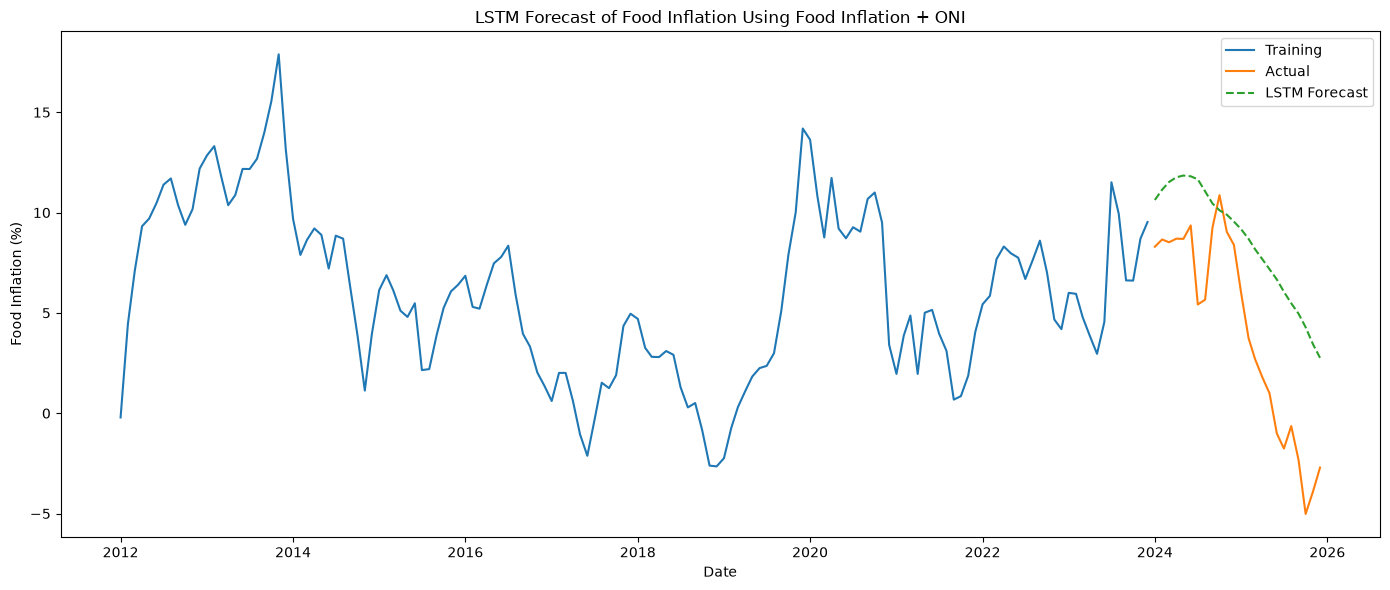

In [25]:
plt.figure(figsize=(14, 6))

plt.plot(
    train_df["date"],
    train_df["food_inflation"],
    label="Training"
)

plt.plot(
    test_df["date"],
    test_df["food_inflation"],
    label="Actual"
)

plt.plot(
    predictions["date"],
    predictions["predicted_food_inflation"],
    linestyle="--",
    label="LSTM Forecast"
)

plt.xlabel("Date")
plt.ylabel("Food Inflation (%)")
plt.title("LSTM Forecast of Food Inflation Using Food Inflation + ONI")
plt.legend()

plt.tight_layout()
plt.show()

In [26]:
predictions.to_csv(
    "../data/processed/lstm_predictions.csv",
    index=False
)

### <mark>**LSTM baseline**</mark>

In [27]:
features_baseline = [
    "food_inflation"
]

In [ ]:
## To be continued